Mastering books to test:

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
books = [
    {
        'book_title': 'Chemistry: A Molecular Approach',
        'bookcode': 'tro_ama6',
        'bookid': '10959',
        'database': "CHEMISTRY"
    },
    {
        'book_title': 'Microbiology: An Introduction',
        'bookid': '7860',
        'bookcode': 'tfc13',
        'database': 'MICROBIOLOGY'
    },
    {
        'book_title': 'University Physics with Modern Physics',
        'bookid': '1122',
        'bookcode': 'yf13',
        'database': 'PHYSICS'
    }
]

In [4]:
%%capture
import sys
import pandas as pd
from src.experiment import run_learning_curve_analysis

output_dir = f'/tmp/aplus/experimental-data'
output_dir = './data'

comps = {}

# Global and local
n_comps = 256
comps['Chemistry: A Molecular Approach'] = n_comps
comps['Microbiology: An Introduction'] = n_comps
comps['University Physics with Modern Physics'] = n_comps 

results = {}
for book in books:
    book_title, book_code = book['book_title'], book['bookcode']
    # This bypasses %%capture
    print(f'Running {book_title}...', file=sys.__stdout__)
    results[book_title] = {}

    # Fetch data from cache
    df = pd.read_csv(f'{output_dir}/{book_code}-2.csv')

    # Remove NA sections
    df = df[~df.section_num.isna()]
    
    # Remove users with too few counts
    item_counts = df.groupby('userId').itemId.nunique()
    valid_users = item_counts[item_counts >= 20].index
    df = df[df["userId"].isin(valid_users)]

    # REMOVE SECTIONS WITH LESS THAN 30 DATAPOINTS
    # Compute number of datapoints per chapter-section
    section_counts = df.groupby(['chapter_num', 'section_num'])['itemId'].count()

    # Keep only sections with ≥30 datapoints
    print(f'Removing {sum(section_counts < 30)} sections...', file=sys.__stdout__)
    valid_sections = section_counts[section_counts >= 30].index  # MultiIndex of (chapter_num, section_num)

    # Filter the dataframe
    df = df.set_index(['chapter_num', 'section_num']).loc[valid_sections].reset_index()

    # Remove items with to few counts
    train_counts = df.groupby("itemId")["isCorrect"].count()
    valid_items = train_counts[train_counts >= 2].index  # ≥2 train responses
    df = df[df["itemId"].isin(valid_items)]

    # Remove items with to few counts
    skill_counts = df.groupby("skillId")["isCorrect"].count()
    valid_skills = skill_counts[skill_counts >= 2].index  # ≥2 train responses
    df = df[df["skillId"].isin(valid_skills)]

    # Limit user count
    # df = df[df.userId.isin(df.userId.unique().tolist()[:1000])] # full trial
    # df = df[df.userId.isin(df.userId.unique().tolist()[:100])] # test trial

    total_irs = len(df[['userId', 'itemId']].drop_duplicates())
    total_users = df['userId'].nunique()
    print(f'Dataset total IRs: {total_irs}', file=sys.__stdout__)
    print(f'Dataset total users: {total_users}', file=sys.__stdout__)
    print(f'Dataset total skills: {df.skillId.nunique()}', file=sys.__stdout__)

    # for error bars
    n_repeats = 5

    # roughly multiples of three
    total_users = 1000
    data_sizes = [total_users]  # None defaults to df length

    # No. of components in MoLA
    n_comps = comps[book_title]

    # Evaluate the four paradigms
    models = ["MoLA"] #, "DINA", "HO-DINA", "GDINA"]

    max_skills = 8
    split_type="chronological"
    aucs, info \
        = run_learning_curve_analysis(
            df, n_comps, data_sizes, n_repeats, models, max_skills=max_skills,
            split_type=split_type # "random" or "chronological"
        )
    # Add meta-data to result payload
    aucs["dataset_size"] = total_irs
    aucs["skill_count"] = df['skillId'].nunique()
    aucs['item_count'] = df['itemId'].nunique()
    aucs['user_count'] = total_users
    results[book_title] = aucs

path = f'results-5/user_count={total_users}&max_skills={max_skills}&n_repeats={n_repeats}&n_comps={n_comps}&split_type={split_type}.json'
with open(path, 'w') as f:
    json.dump(results, f)

print(f'Results saved to {path}', file=sys.__stdout__)

Running Chemistry: A Molecular Approach...
Removing 14 sections...
Dataset total IRs: 1993417
Dataset total users: 9557
Dataset total skills: 246
Mask percentage: 0.1981110826284716
Max skills in section: 8.
Min skills in section: 2.
Running size=1000...
[np.float64(96839.25603149936), np.float64(81447.85279256907), np.float64(79862.65111749666), np.float64(79536.59967428175), np.float64(79408.55002677291), np.float64(79331.41662488713), np.float64(79271.27152037207), np.float64(79216.82316761887), np.float64(79162.51817700718), np.float64(79105.54055665155), np.float64(79046.80293923093), np.float64(78988.83184292214), np.float64(78933.73004490623), np.float64(78882.51733943238), np.float64(78834.33926874275), np.float64(78788.67076931162), np.float64(78747.63517485018), np.float64(78711.49257602764), np.float64(78679.60677817487), np.float64(78651.60346270916), np.float64(78626.94842761915), np.float64(78605.28794705066), np.float64(78586.38786615778), np.float64(78569.93610513113), 

In [15]:
total_users

9797

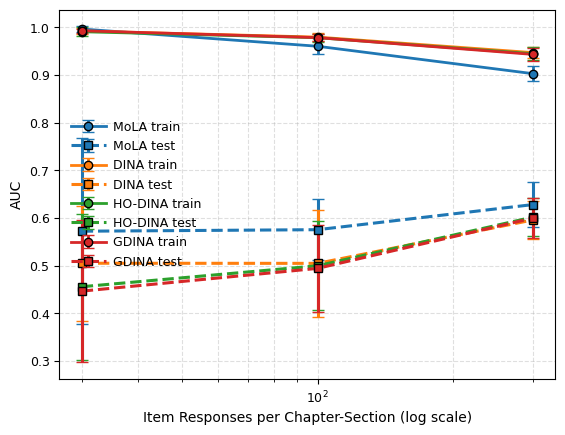

In [38]:
from src.visualize import plot_learning_curve_analysis
fig, ax = plt.subplots()

# 10,000 components - phyiscs
plot_learning_curve_analysis(ax, results, book_title)

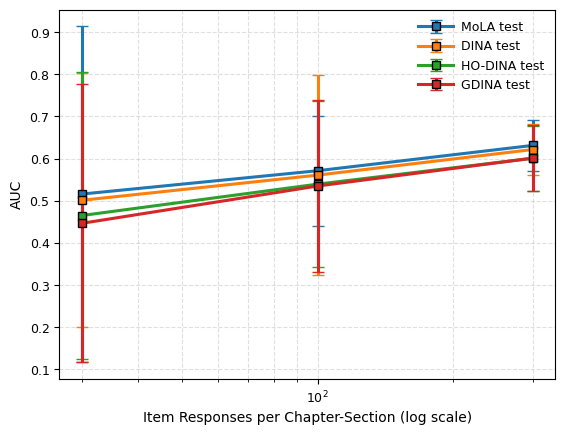

In [34]:
from src.visualize import plot_learning_curve_analysis
fig, ax = plt.subplots()

# 10,000 components - phyiscs
plot_learning_curve_analysis(ax, results, book_title)

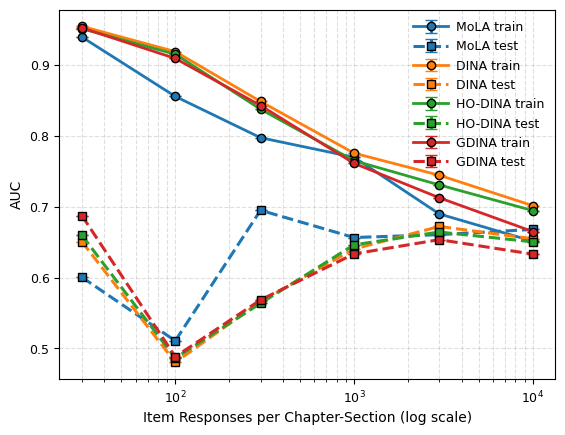

In [27]:
from src.visualize import plot_learning_curve_analysis
fig, ax = plt.subplots()

# 10,000 components - phyiscs
plot_learning_curve_analysis(ax, results, book_title)

In [10]:
# GDINA
results

{'Chemistry: A Molecular Approach': {'GDINA': [{'train_auc': 0.9551495182833517,
    'test_auc': 0.5887640770593952,
    'train_brier': 0.5276011620283484,
    'test_brier': 0.317698199484848,
    'train_nll': 0.26043988342342056,
    'test_nll': 2.6679717611997043,
    'train_n_obs': 19334,
    'test_n_obs': 4917,
    'data': {'test': {'y_proba': [0.8004139867217847,
       0.7316841188261001,
       0.7902061813903312,
       0.8122026619687873,
       0.7690755047511745,
       0.6247117003765907,
       0.0,
       0.6974200854103484,
       0.810005810356645,
       0.9999999997917886,
       0.4602155802432464,
       0.8771069644935331,
       0.9999999992471788,
       0.9649951972103938,
       0.999999999979621,
       0.36500226068991,
       0.8332439961458167,
       0.9999999995986945,
       0.9999999999726397,
       0.8151430087697821,
       0.0,
       0.0,
       0.0,
       0.0,
       0.9999999952826185,
       0.9999999998958462,
       0.013299935890995944,
    

In [15]:
# HO-DINA
[r['test_auc'] for r in results['University Physics with Modern Physics']['HO-DINA']]

[0.623482346964694, 0.6301654153695906]

In [10]:
# DINA
results

{'University Physics with Modern Physics': {'HO-DINA': [{'train_auc': 0.9374752688964045,
    'test_auc': 0.623482346964694,
    'train_brier': 0.5429725063259955,
    'test_brier': 0.34546112048852184,
    'train_nll': 0.2616964494983891,
    'test_nll': 3.328612809279991,
    'train_n_obs': 16870,
    'test_n_obs': 4332,
    'data': {'test': {'y_proba': [0.0,
       0.9999999999419503,
       0.9999999997000011,
       0.9999999997078175,
       0.3971166899114344,
       0.3225354535017925,
       0.47828633166655576,
       0.5506353041709997,
       0.0,
       0.9999999999563103,
       0.5634890105610391,
       0.563489010230441,
       0.0,
       0.9999999999331112,
       0.9999999997085839,
       0.0,
       0.9999999997922129,
       0.9999999999609882,
       0.9999518327914755,
       0.9999518327914755,
       0.574473634874937,
       0.0,
       0.5863673931158383,
       0.5819482314436575,
       0.8819190047148953,
       0.9999999999620722,
       4.3461104575272

In [21]:
# MoLA
[r['test_auc'] for r in results['University Physics with Modern Physics']['MoLA']]

[0.680460700389105, 0.6936507936507936]

              bin  mean_pred  mean_true  count
0  (0.291, 0.354]   0.320402   0.500000     16
1  (0.354, 0.416]   0.386604   0.545455     33
2  (0.416, 0.478]   0.442464   0.611111     36
3   (0.478, 0.54]   0.508070   0.741176    170
4   (0.54, 0.602]   0.587557   0.735294     68
5  (0.602, 0.664]   0.621555   0.737705     61
6  (0.664, 0.727]   0.684126   0.765625     64
7  (0.727, 0.789]   0.750278   0.777778     45
8  (0.789, 0.851]   0.808199   0.754386     57
9  (0.851, 0.913]   0.912726   1.000000     11


/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_43707/3059598586.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = data.groupby('bin').agg(


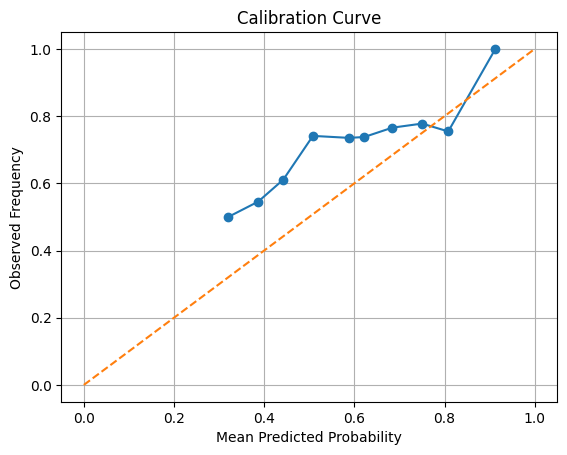

In [19]:
# MoLA
data = pd.DataFrame(results[book_title]['MoLA'][0]['data']['test'])

# number of bins
n_bins = 10

# create bins
data['bin'] = pd.cut(data['y_proba'], bins=n_bins)

# group by bins and compute stats
calibration = data.groupby('bin').agg(
    mean_pred=('y_proba', 'mean'),
    mean_true=('y_true', 'mean'),
    count=('y_true', 'size')
).reset_index()

print(calibration)

import matplotlib.pyplot as plt

plt.plot(calibration['mean_pred'], calibration['mean_true'], marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')  # perfect calibration line

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Frequency')
plt.title('Calibration Curve')

plt.grid()
plt.show()

In [29]:
# total number of samples
N = len(data)

# compute ECE
ece = (
    (calibration['count'] / N) *
    (calibration['mean_true'] - calibration['mean_pred']).abs()
).sum()

print(f"ECE: {ece:.6f}")

def compute_calibration_and_ece(data, n_bins=10, quantile=False):
    df = data.copy()
    
    # binning
    if quantile:
        df['bin'] = pd.qcut(df['y_proba'], q=n_bins, duplicates='drop')
    else:
        df['bin'] = pd.cut(df['y_proba'], bins=n_bins)
    
    # aggregation
    calibration = df.groupby('bin').agg(
        mean_pred=('y_proba', 'mean'),
        mean_true=('y_true', 'mean'),
        count=('y_true', 'size')
    ).reset_index()
    
    # sort for plotting
    calibration = calibration.sort_values('mean_pred')
    
    # ECE
    N = len(df)
    ece = (
        (calibration['count'] / N) *
        (calibration['mean_true'] - calibration['mean_pred']).abs()
    ).sum()
    
    return calibration, ece

ECE: 0.214946


In [11]:
#DINA
results

{'Chemistry: A Molecular Approach': {'DINA': {10000: {'train': [0.706723548628857],
    'test': [0.6644610206579387]}}}}

In [16]:
# import json
# with open(f'results-2/3-books-10000-comps-mola.json', 'w') as f:
#     json.dump(results, f)

results

{'Chemistry: A Molecular Approach': {'MoLA': {1000: {'train': [0.7024674694883785],
    'test': [0.6519379556740905]}}}}

In [ ]:
from src.visualize import plot_learning_curve_analysis
fig, ax = plt.subplots()

# 100,000 components
plot_learning_curve_analysis(ax, results, book_title)

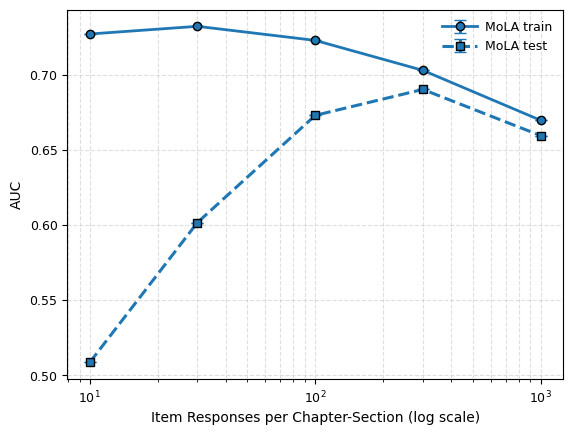

In [ ]:
from src.visualize import plot_learning_curve_analysis
fig, ax = plt.subplots()

# 10,000 components - phyiscs
plot_learning_curve_analysis(ax, results, book_title)

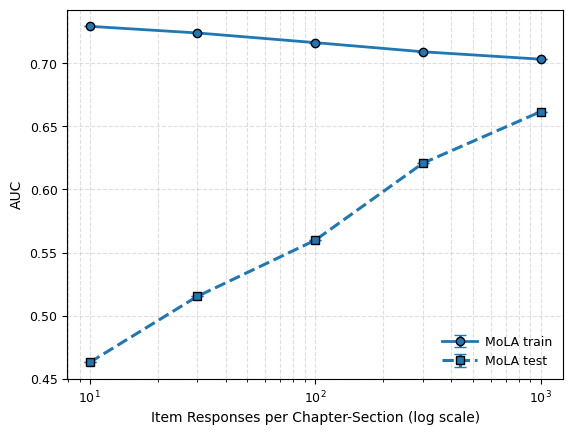

In [ ]:
from src.visualize import plot_learning_curve_analysis
fig, ax = plt.subplots()

# 10,000 components - chemsitry
plot_learning_curve_analysis(ax, results, book_title)

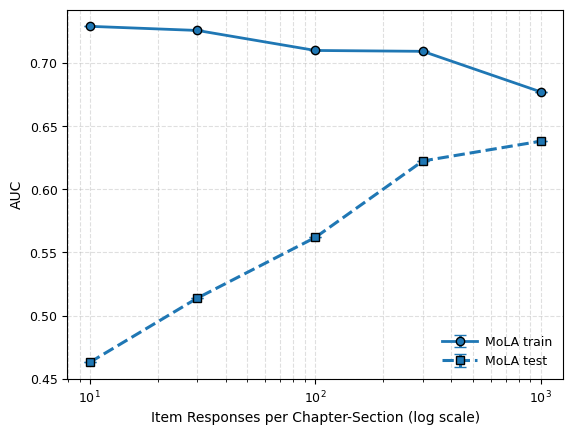

In [ ]:
from src.visualize import plot_learning_curve_analysis
fig, ax = plt.subplots()

# 1,000 components - chemsitry
plot_learning_curve_analysis(ax, results, book_title)

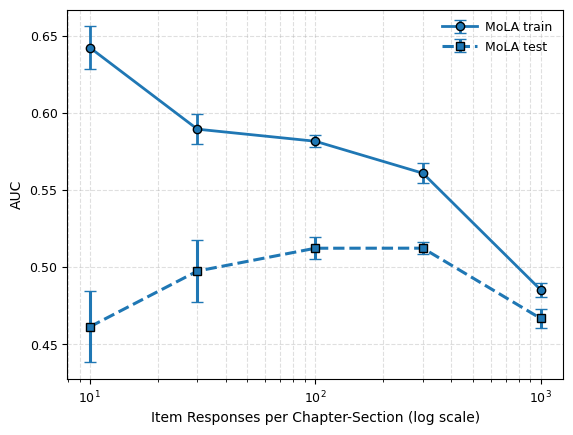

In [ ]:
from src.visualize import plot_learning_curve_analysis

fig, ax = plt.subplots()

# 5-components - chemistry
plot_learning_curve_analysis(ax, results, book_title)

In [6]:
f'results-2/{book_title}.json'

'results-2/Microbiology: An Introduction.json'

In [ ]:
# import json
# with open(f'results-2/{book_title}.json', 'w') as f:
#     json.dump(results_, f)

In [ ]:
# book_title = 'Chemistry: A Molecular Approach'
# with open(f'results-2/{book_title}.json', 'r') as f:
#     results_ = json.load(f)

(0.0, 1.0)

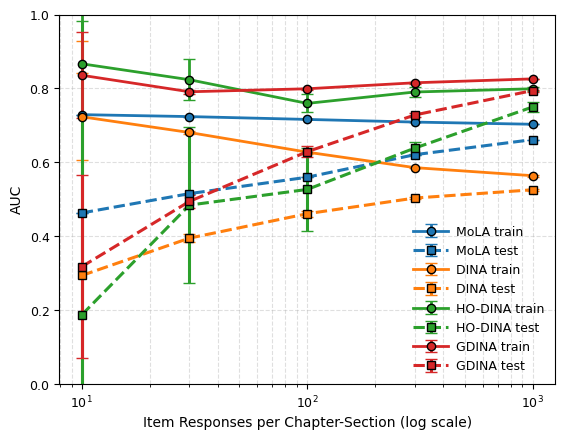

In [32]:
from src.visualize import plot_learning_curve_analysis

fig, ax = plt.subplots()

plot_learning_curve_analysis(ax, results_, book_title)
plt.ylim(0, 1)

(0.0, 1.0)

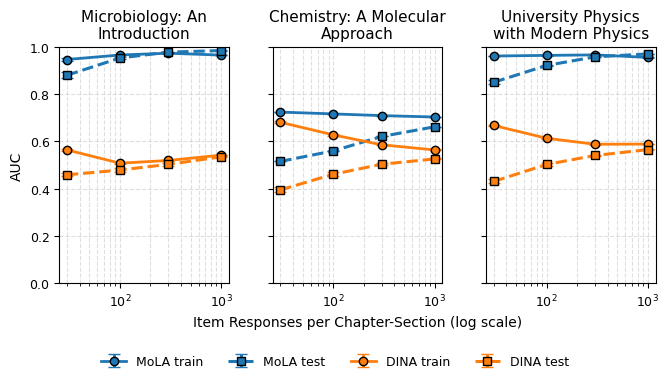

In [ ]:
import json
results = []
for book in books:
    book_title = book['book_title']
    with open(f'results-2/{book_title}.json', 'r') as f:
        result = json.load(f)
        results.append(result)

n = len(results)
from src.visualize import plot_learning_curve_analysis
import textwrap

def wrap_title(s, width=22):
    return "\n".join(textwrap.wrap(s, width=width))

fig, axes = plt.subplots(
    1, n,
    figsize=(6.8, 3.5),
    sharey=True
)

# Make axes iterable if n == 1
axes = np.atleast_1d(axes)

for ax, result in zip(axes, results):
    book_title = list(result.keys())[0]

    ax.set_title(wrap_title(book_title, width=22), fontsize=11)
    plot_learning_curve_analysis(ax, result, book_title)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    ax.legend_.remove()

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.10) # -0.04
)

fig.subplots_adjust(bottom=0.25)
fig.tight_layout()

title = 'figures/exp-2-3-books_auc_vs_data_size'

fig.subplots_adjust(top=0.85)

for i, ax in enumerate(axes):
    if i != 0:
        ax.set_ylabel("")
    if i != n // 2:
        ax.set_xlabel("")

# for i, ax in enumerate(axes):
#     if i != n // 2:
#         ax.set_xlabel("")

# plt.savefig(f"{title}-2.pdf", bbox_inches="tight")
# plt.savefig(f"{title}-2.svg", bbox_inches="tight")
# plt.savefig(f"{title}-2.png", dpi=300, bbox_inches="tight")

AttributeError: 'str' object has no attribute 'keys'

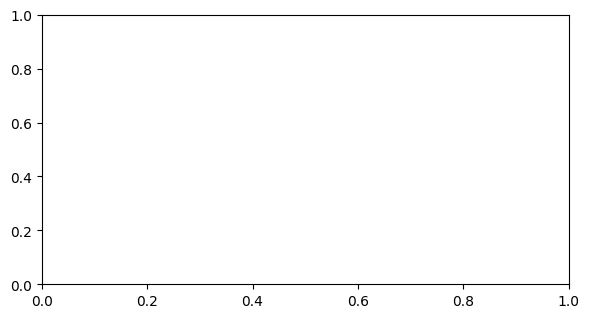

In [ ]:

import numpy as np


n = len(results)
from src.visualize import plot_learning_curve_analysis
import textwrap

def wrap_title(s, width=22):
    return "\n".join(textwrap.wrap(s, width=width))

fig, axes = plt.subplots(
    1, n,
    figsize=(6.8, 3.5),
    sharey=True
)

# Make axes iterable if n == 1
axes = np.atleast_1d(axes)

for ax, result in zip(axes, results):
    book_title = list(result.keys())[0]
    r = result[book_title]
    
    mola_aucs = r['mola_aucs']
    dina_aucs = r['dina_aucs']

    ax.set_title(wrap_title(book_title, width=22), fontsize=11)
    
    plot_learning_curve_analysis(ax, mola_aucs, dina_aucs, book_title)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    ax.legend_.remove()

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.04)
)

fig.subplots_adjust(bottom=0.25)
fig.tight_layout()

title = 'figures/3-books_auc_vs_data_size'

fig.subplots_adjust(top=0.85)

for i, ax in enumerate(axes):
    if i != 0:
        ax.set_ylabel("")
    if i != n // 2:
        ax.set_xlabel("")

for i, ax in enumerate(axes):
    if i != n // 2:
        ax.set_xlabel("")

# plt.savefig(f"{title}-1.pdf", bbox_inches="tight")
# plt.savefig(f"{title}-1.svg", bbox_inches="tight")
# plt.savefig(f"{title}-1.png", dpi=300, bbox_inches="tight")

In [17]:
aucs

{'MoLA': {1000: {'train': [0.965369309762254], 'test': [0.9843959999727487]}}}

In [19]:
aucs

{'HO-DINA': {1000: {'train': [0.8340700669757857],
   'test': [0.8382049748755145]}}}

In [9]:
aucs

{'GDINA': {30: {'train': [0.7639579386988538], 'test': [0.9260099088568077]}}}

In [7]:
aucs

{'DINA': {30: {'train': [0.6369749856651375], 'test': [0.9852888086642599]}}}